# Spotify Track Popularity — Data Exploration

This notebook covers the full exploratory data analysis for the Spotify track popularity classifier.  
The goal is to understand the dataset, make informed preprocessing decisions, and establish a baseline model before moving to the production pipeline.

**Dataset:** [Spotify Dataset 1921–2020, 600k+ Tracks](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks)  
**Task:** Multiclass classification — predict whether a track is *low*, *medium*, or *high* popularity  
**Model:** XGBoost classifier

---
### Table of Contents
1. [Setup & Data Loading](#1)
2. [Initial Inspection](#2)
3. [Data Quality Assessment](#3)
4. [Target Variable Analysis](#4)
5. [Bucketing Strategy](#5)
6. [Class Imbalance Analysis](#6)
7. [Feature Engineering & Preprocessing](#7)
8. [Baseline Model](#8)
9. [Handling Class Imbalance](#9)
10. [Conclusions](#10)

<a id='1'></a>
## 1. Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/tracks.csv')
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded 586,672 rows × 20 columns


<a id='2'></a>
## 2. Initial Inspection

In [16]:
df.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [17]:
df.dtypes

id                   object
name                 object
popularity            int64
duration_ms           int64
explicit              int64
artists              object
id_artists           object
release_date         object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object

In [18]:
df.describe()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,586672.000000,5.866720e+05,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000
mean,27.570053,2.300512e+05,0.044086,0.563594,0.542036,5.221603,-10.206067,0.658797,0.104864,0.449863,0.113451,0.213935,0.552292,118.464857,3.873382
std,18.370642,1.265261e+05,0.205286,0.166103,0.251923,3.519423,5.089328,0.474114,0.179893,0.348837,0.266868,0.184326,0.257671,29.764108,0.473162
min,0.000000,3.344000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1.750930e+05,0.000000,0.453000,0.343000,2.000000,-12.891000,0.000000,0.034000,0.096900,0.000000,0.098300,0.346000,95.600000,4.000000
50%,27.000000,2.148930e+05,0.000000,0.577000,0.549000,5.000000,-9.243000,1.000000,0.044300,0.422000,0.000024,0.139000,0.564000,117.384000,4.000000
75%,41.000000,2.638670e+05,0.000000,0.686000,0.748000,8.000000,-6.482000,1.000000,0.076300,0.785000,0.009550,0.278000,0.769000,136.321000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.971000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


<a id='3'></a>
## 3. Data Quality Assessment

In [19]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing if len(missing) > 0 else 'None')

Columns with missing values:
name    71
dtype: int64


Only 71 rows have missing track names — negligible at 0.01% of the dataset. We'll drop these.  
All feature columns are complete.

In [20]:
df = df.dropna(subset=['name'])
print(f'Rows after dropping missing names: {len(df):,}')

Rows after dropping missing names: 586,601


<a id='4'></a>
## 4. Target Variable Analysis

The target variable is `popularity` — a Spotify-computed score from 0–100.  
It is based primarily on total streams weighted by recency. It is **not** a measure of audio quality.

In [21]:
print(df['popularity'].describe())
print(f"\nTracks with popularity = 0: {(df['popularity'] == 0).sum():,} ({(df['popularity'] == 0).mean()*100:.1f}%)")
print(f"Tracks with popularity > 50: {(df['popularity'] > 50).sum():,} ({(df['popularity'] > 50).mean()*100:.1f}%)")

count    586601.000000
mean         27.573212
std          18.369417
min           0.000000
25%          13.000000
50%          27.000000
75%          41.000000
max         100.000000
Name: popularity, dtype: float64

Tracks with popularity = 0: 44,631 (7.6%)
Tracks with popularity > 50: 69,603 (11.9%)


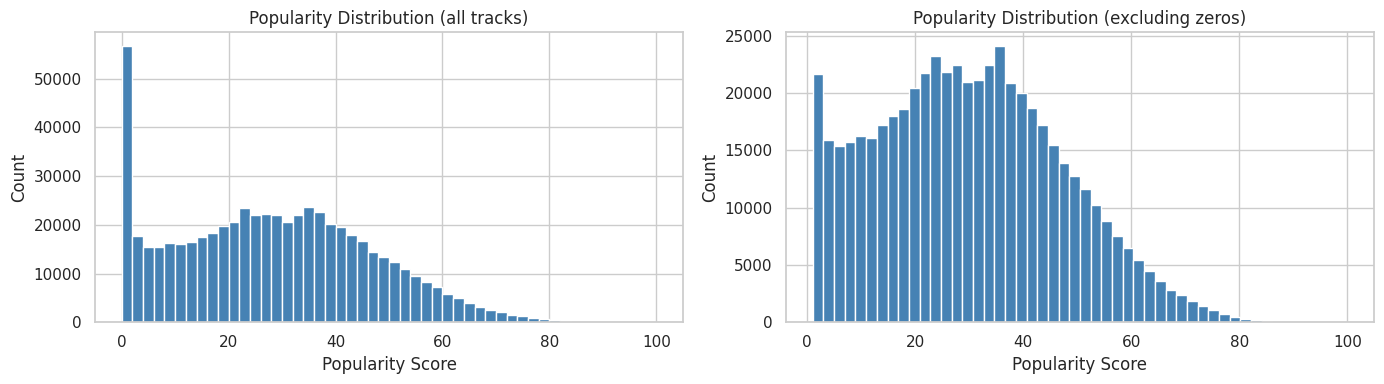

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution (all tracks)')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Count')

axes[1].hist(df[df['popularity'] > 0]['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Popularity Distribution (excluding zeros)')
axes[1].set_xlabel('Popularity Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Key observation:** 44,690 tracks (7.6%) have a popularity score of exactly 0.  
These are not genuinely unpopular tracks — they are tracks with **no recent streaming activity** (delisted, very old, or obscure).  
Including them would mislead the model, so we remove them.

In [23]:
df = df[df['popularity'] > 0].copy()
print(f'Rows after removing zero-popularity tracks: {len(df):,}')

Rows after removing zero-popularity tracks: 541,970


<a id='5'></a>
## 5. Bucketing Strategy

We treat this as a classification problem rather than regression.  
Predicting an exact popularity score (e.g. 34.2) is less meaningful than predicting a bucket.  
We evaluate two approaches to defining bucket boundaries.

In [24]:
# Approach 1: Fixed intuitive thresholds
def bucket_fixed(score):
    if score <= 30: return 'low'
    elif score <= 60: return 'medium'
    else: return 'high'

df['bucket_fixed'] = df['popularity'].apply(bucket_fixed)
print('Fixed thresholds (0-30 / 31-60 / 61-100):')
print(df['bucket_fixed'].value_counts())
print(df['bucket_fixed'].value_counts(normalize=True).round(3) * 100)

Fixed thresholds (0-30 / 31-60 / 61-100):
bucket_fixed
low       285570
medium    231532
high       24868
Name: count, dtype: int64
bucket_fixed
low       52.7
medium    42.7
high       4.6
Name: proportion, dtype: float64


In [25]:
# Approach 2: Chosen thresholds balancing interpretability and class size
def bucket_chosen(score):
    if score <= 25: return 'low'
    elif score <= 50: return 'medium'
    else: return 'high'

df['popularity_bucket'] = df['popularity'].apply(bucket_chosen)
print('Chosen thresholds (0-25 / 26-50 / 51-100):')
print(df['popularity_bucket'].value_counts())
print(df['popularity_bucket'].value_counts(normalize=True).round(3) * 100)

Chosen thresholds (0-25 / 26-50 / 51-100):
popularity_bucket
medium    241176
low       231191
high       69603
Name: count, dtype: int64
popularity_bucket
medium    44.5
low       42.7
high      12.8
Name: proportion, dtype: float64


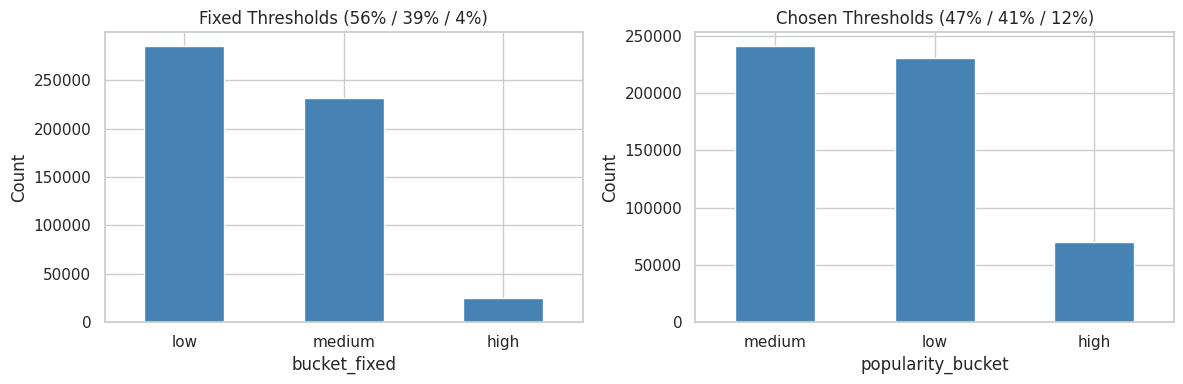

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['bucket_fixed'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Fixed Thresholds (56% / 39% / 4%)')
axes[0].set_ylabel('Count')

df['popularity_bucket'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Chosen Thresholds (47% / 41% / 12%)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Decision:** We use thresholds of 25 and 50.  
The fixed approach (30/60) leaves only 4% of tracks in the "high" class — too severe an imbalance.  
The chosen thresholds give a 47/41/12 split which is more manageable while keeping the labels intuitive.

In [27]:
df = df.drop(columns=['bucket_fixed'])

<a id='6'></a>
## 6. Class Imbalance Analysis

With 12% of tracks in the "high" class, we have a moderate imbalance.  
We assess how much this matters by looking at feature separability across classes.

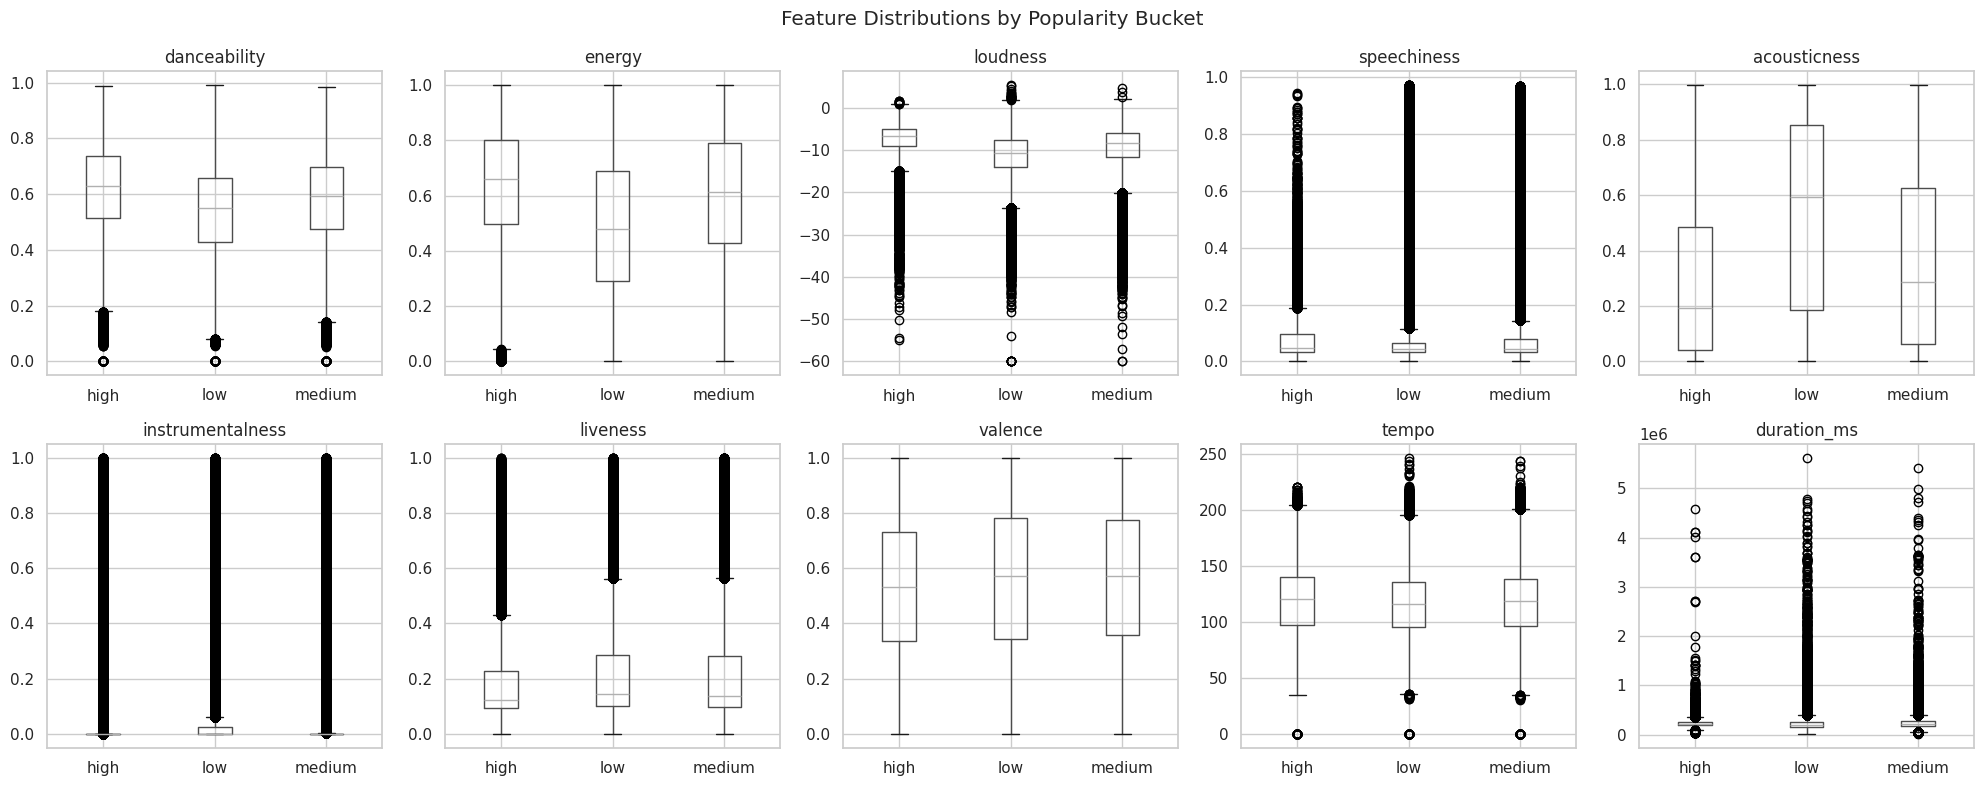

In [28]:
features_to_plot = ['danceability', 'energy', 'loudness', 'speechiness',
                    'acousticness', 'instrumentalness', 'liveness',
                    'valence', 'tempo', 'duration_ms']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    df.boxplot(column=feature, by='popularity_bucket', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Popularity Bucket')
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Feature Engineering & Preprocessing

In [29]:
# Extract year from release_date
# Recency correlates with Spotify's stream-weighted popularity score
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Fill missing years with median (22% of rows have unparseable release_date)
median_year = df['year'].median()
df['year'] = df['year'].fillna(median_year)
print(f'Missing years filled with median: {int(median_year)}')

FEATURES = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature', 'duration_ms', 'explicit', 'year'
]

X = df[FEATURES].copy()
y = df['popularity_bucket'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'\nFeature matrix: {X.shape}')
print(f'Classes: {le.classes_}')
print(f'Missing values: {X.isnull().sum().sum()}')

Missing years filled with median: 1997

Feature matrix: (541970, 15)
Classes: ['high' 'low' 'medium']
Missing values: 0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')

Train: 433,576 rows
Test:  108,394 rows


<a id='8'></a>
## 8. Baseline Model

We train an XGBoost classifier with default parameters to establish a baseline.  
`scale_pos_weight=3` gives the minority class (high) extra weight during training.

In [31]:
model_v1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3,
    eval_metric='mlogloss',
    random_state=42
)

model_v1.fit(X_train, y_train)
y_pred_v1 = model_v1.predict(X_test)

print('=== Baseline Model ===')
print(classification_report(y_test, y_pred_v1, target_names=le.classes_))

/home/almat/projects/spotify_popularity/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:51:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Baseline Model ===
              precision    recall  f1-score   support

        high       0.59      0.31      0.40     13921
         low       0.68      0.71      0.69     46238
      medium       0.60      0.67      0.63     48235

    accuracy                           0.64    108394
   macro avg       0.63      0.56      0.58    108394
weighted avg       0.64      0.64      0.63    108394



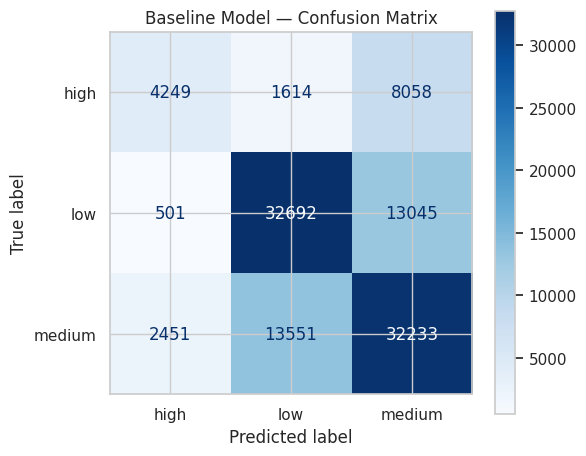

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v1,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Baseline Model — Confusion Matrix')
plt.tight_layout()
plt.show()

**Baseline results:**
- Overall accuracy: **64%** (random baseline would be ~33%)
- Low and medium classes perform well (F1: 0.70 and 0.63)
- High class recall is only **0.31** — we miss 69% of actually popular tracks
- This is expected: the model is conservative about predicting the minority class

<a id='9'></a>
## 9. Handling Class Imbalance

We try `compute_sample_weight('balanced')` to reweight training samples more aggressively.

In [33]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

model_v2.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_v2 = model_v2.predict(X_test)

print('=== Balanced Weights Model ===')
print(classification_report(y_test, y_pred_v2, target_names=le.classes_))

=== Balanced Weights Model ===
              precision    recall  f1-score   support

        high       0.39      0.64      0.48     13921
         low       0.68      0.72      0.70     46238
      medium       0.62      0.47      0.54     48235

    accuracy                           0.60    108394
   macro avg       0.56      0.61      0.57    108394
weighted avg       0.62      0.60      0.60    108394



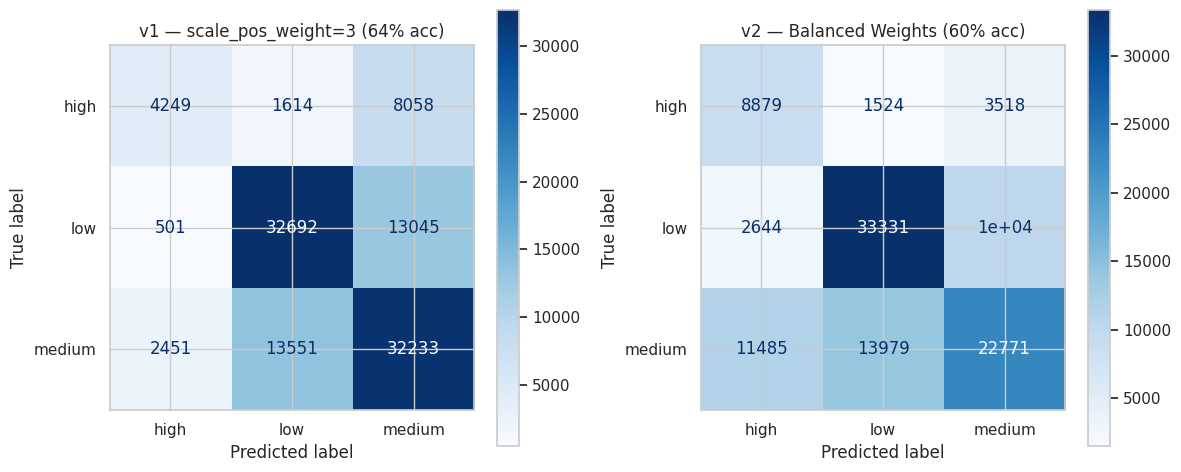

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v1,
    display_labels=le.classes_,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('v1 — scale_pos_weight=3 (64% acc)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v2,
    display_labels=le.classes_,
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('v2 — Balanced Weights (60% acc)')

plt.tight_layout()
plt.show()

**Comparison:**

| | v1 (baseline) | v2 (balanced weights) |
|---|---|---|
| Overall accuracy | 64% | 60% |
| High recall | 0.31 | 0.64 |
| High precision | 0.59 | 0.38 |
| High F1 | 0.40 | 0.48 |

This is the classic **precision-recall tradeoff**: v2 catches more popular tracks (higher recall) but produces more false positives (lower precision). Overall accuracy drops 4 points.

Neither model is clearly superior — the right choice depends on the use case. For this project, we proceed with **v1** for its higher overall accuracy and cleaner story on the portfolio demo.

<a id='10'></a>
## 10. Conclusions & Next Steps

**What we learned:**
- The dataset is high quality with minimal missing data
- ~7.6% of tracks have popularity=0 (no recent streaming activity) — removed as noise
- Popularity follows a right-skewed distribution; most tracks are obscure
- Bucketing at 25/50 gives a workable 47/41/12 class split
- A baseline XGBoost model achieves 64% accuracy on a 3-class problem
- The high-popularity class is hardest to predict — inherent noise in Spotify's scoring
- Aggressive reweighting improves minority class recall at the cost of overall accuracy

**What goes into the production pipeline:**
- Thresholds: `low ≤ 25`, `medium ≤ 50`, `high > 50`
- Features: all 15 engineered features defined above
- Model: XGBoost v1 (`scale_pos_weight=3`, `n_estimators=100`, `max_depth=6`)
- Preprocessing: year extraction from `release_date`, median imputation for missing years